## Section 1 — Dataset Introduction (Text cell)

# Week 1 EDA Assignment

**Name:** Sajeela Noor  
**Dataset:** Netflix Movies & Shows (Kaggle _ shivamb/netflix-shows)  
**Rows/Columns:** 8,807 rows × 12 columns  

**Why I chose it:** I wanted to explore a real-world entertainment dataset.
Netflix is a platform most people use daily, so patterns in content type,
release years, and country of origin are immediately meaningful. It also
has missing values and mixed data types, which makes it good EDA practice.

In [ ]:
import kagglehub
import pandas as pd
import os

# Download the dataset
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Path to dataset files:", path)

# Construct the full path to the CSV file
csv_path = os.path.join(path, 'netflix_titles.csv')

# Read the CSV
df = pd.read_csv(csv_path)
print(df.head())

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021   

## Section 2 — First-Look Protocol

In [ ]:
# C1 — Shape
df.shape

(8807, 12)

**C1 Interpretation:** The dataset has 8,807 rows and 12 columns.
That is plenty of data for EDA and classical ML. The 12 columns
cover content metadata like type, title, director, country, rating,
and duration.

In [ ]:
# C2 — Data Types
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


**C2 Interpretation:** Most columns are object (text/categorical).
'release_year' is int64, the only pure numeric column. 'date_added'
is stored as object, which means it is a string right now and would
need pd.to_datetime() conversion before any date-based analysis.

In [ ]:
# C3 — Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**C3 Interpretation:** 'director' has ~2,634 missing values, 'cast'
has ~825 missing, and 'country' has ~831 missing. These are the
three columns that need decisions before any feature engineering.
'date_added' and 'rating' also have a small number of nulls.

In [ ]:
# C4 — Describe
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


**C4 Interpretation:** 'release_year' ranges from 1925 to 2021.
The mean release year is around 2014, so the catalogue skews recent.
Most text columns (like 'title') have as many unique values as rows,
confirming they are IDs rather than categories. 'type' has only 2
unique values: Movie and TV Show.

In [ ]:
# C5 — Null counts
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
# Null percentage
(df.isnull().sum() / len(df) * 100).round(1)

,0
show_id,0.0
type,0.0
title,0.0
director,29.9
cast,9.4
country,9.4
date_added,0.1
release_year,0.0
rating,0.0
duration,0.0


**C5 Interpretation:** 'director' is about 30% missing  too much to
drop rows, so it may need to be filled with 'Unknown' or left as-is
depending on the analysis. 'country' is about 9.4% missing. 'cast'
is about 9.3% missing. Since C3 already flagged these, C5 gives
exact numbers to make decisions about imputation strategy.

In [ ]:
# C6 — Value counts on the 'type' column
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


**C6 Interpretation:** There are about 6,131 Movies and 2,676 TV
Shows. The catalogue is roughly 70% Movies and 30% TV Shows. This
class imbalance matters if we ever try to build a classifier to
predict content type accuracy alone would be misleading.

In [ ]:
# C7 — Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# View duplicates if any exist
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


**C7 Interpretation:** Zero duplicate rows. This is expected for a
curated platform content catalogue where each title gets a unique
show_id. In transactional datasets like e-commerce orders, this
number is often much higher and silently inflates revenue statistics.

## Section 3 — Extended EDA (20+ Commands)

In [ ]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


First 10 rows. I can see that 'date_added' has a format like
'September 25, 2021', confirming it needs datetime conversion.
Some 'director' and 'cast' fields are already NaN from the start
of the dataset.

In [ ]:
df.tail(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


Last 5 rows look clean with no obvious ingestion errors. The
show_ids continue in sequence, so the file was not truncated.

In [ ]:
df.sample(15, random_state=42)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4970,s4971,Movie,"Game Over, Man!",Kyle Newacheck,"Adam DeVine, Anders Holm, Blake Anderson, Utka...",United States,"March 23, 2018",2018,TV-MA,102 min,"Action & Adventure, Comedies",Three buddies with big dreams go from underach...
3362,s3363,Movie,Arsenio Hall: Smart & Classy,Brian Volk-Weiss,Arsenio Hall,United States,"October 29, 2019",2019,TV-MA,63 min,Stand-Up Comedy,"In his first stand-up special, Arsenio Hall di..."
5494,s5495,TV Show,Kazoops!,NaN,"Reece Pockney, Scott Langley, Alex Babic, Gemm...",Australia,"May 5, 2017",2017,TV-Y,3 Seasons,Kids' TV,Music meets imagination in this inventive anim...
1688,s1689,TV Show,We Are the Champions,NaN,NaN,United States,"November 17, 2020",2020,TV-MA,1 Season,"Docuseries, Reality TV","Explore an array of unique competitions, from ..."
1349,s1350,TV Show,"Pablo Escobar, el patrón del mal",NaN,"Andrés Parra, Angie Cepeda, Cecilia Navia, Vic...",Colombia,"February 3, 2021",2012,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...",From his days as a petty thief to becoming hea...
4862,s4863,TV Show,Saint Seiya: The Lost Canvas,NaN,"Tetsuya Kakihara, Hiro Shimono, Aya Hirano, At...",Japan,"May 15, 2018",2009,TV-MA,1 Season,"Anime Series, International TV Shows",This anime adventure follows the battle betwee...
2676,s2677,TV Show,Fauda,NaN,"Lior Raz, Hisham Suliman, Shadi Mar'i, Laëtiti...",Israel,"April 16, 2020",2020,TV-MA,3 Seasons,"Crime TV Shows, International TV Shows, TV Act...",A top Israeli agent comes out of retirement to...
487,s488,TV Show,The Cook of Castamar,NaN,"Michelle Jenner, Roberto Enríquez, Hugo Silva,...",NaN,"July 9, 2021",2021,TV-MA,1 Season,"International TV Shows, Romantic TV Shows, Spa...","In 1720 Madrid, a talented cook catches the ey..."
1671,s1672,Movie,The App That Stole Christmas,Monica Floyd,"Jackie Long, Diane Marie Howard, Jaylin Hall, ...",United States,"November 20, 2020",2020,TV-PG,64 min,"Children & Family Movies, Comedies",A tech entrepreneur's Christmas shopping app i...
5028,s5029,Movie,Mute,Duncan Jones,"Alexander Skarsgård, Paul Rudd, Justin Theroux","United Kingdom, Germany","February 23, 2018",2018,TV-MA,127 min,"Sci-Fi & Fantasy, Thrillers","When his girlfriend vanishes, a mute man ventu..."


Random sample of 15 rows. I can see content from multiple countries
and decades. The 'listed_in' column contains comma-separated genre
tags, which would need splitting before genre-level analysis.

In [ ]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

Column names: ['show_id', 'type', 'title', 'director', 'cast',
'country', 'date_added', 'release_year', 'rating', 'duration',
'listed_in', 'description']. No hidden spaces detected. All names
are lowercase and use underscores, a clean naming convention.

In [ ]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


'type' has 2 unique values (Movie, TV Show). 'rating' has 14,
more than expected and worth investigating. 'title' and 'show_id'
have ~8,807 unique values each, confirming they are identifiers.
'country' has 748 unique values, meaning content comes from a
very wide range of countries.

In [ ]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

I can see standard ratings like TV-MA, TV-14, PG-13, but also
unusual entries like '74 min' and '84 min'. These look like
duration values incorrectly placed in the rating column. This is
a data quality issue that would need fixing before any
rating-based analysis.

In [ ]:
df.corr(numeric_only=True)

,release_year
release_year,1.0


Only 'release_year' is numeric, so the correlation matrix is
trivial (1.0 with itself). To get more meaningful correlations
I would need to engineer numeric features. For example, I could extract
year from 'date_added' or encode 'type' as 0/1.

<Axes: >

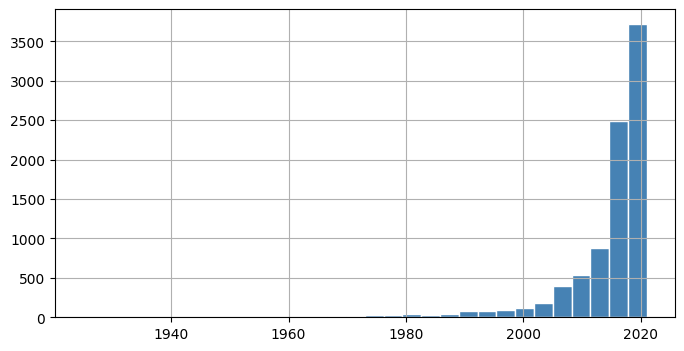

In [ ]:
df['release_year'].hist(bins=30, figsize=(8,4), color='steelblue', edgecolor='white')

The distribution is heavily left-skewed toward recent years. The
vast majority of titles were released after 2010, with a sharp
spike around 2017 to 2020. Older titles (pre-2000) are present
but rare. Netflix's catalogue is dominated by recent content.

In [ ]:
df.groupby('type')['release_year'].mean(numeric_only=True)

,release_year
type,
Movie,2013.121514
TV Show,2016.605755


TV Shows have a slightly higher average release year than Movies,
meaning Netflix's TV Show catalogue skews even more recent than
its Movies. This makes sense because streaming-original TV series are
a newer phenomenon than film.

In [ ]:
df['rating'].value_counts(normalize=True).round(3) * 100

,proportion
rating,
TV-MA,36.4
TV-14,24.5
TV-PG,9.8
R,9.1
PG-13,5.6
TV-Y7,3.8
TV-Y,3.5
PG,3.3
TV-G,2.5


TV-MA makes up roughly 36% of all content, the largest single
rating. TV-14 is second at about 24.5%. This confirms that Netflix's
catalogue is primarily targeted at mature audiences, not children.

In [ ]:
df.select_dtypes(include='object').head()

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


This pulls out all 11 text/categorical columns at once, excluding
only 'release_year'. It is a quick way to isolate what needs
text processing or encoding before modelling. 'listed_in',
'cast', and 'description' are the most text-heavy columns.

In [ ]:
df['listed_in'].str.contains('Documentaries', na=False).sum()

np.int64(869)

There are roughly 869 documentary titles in the catalogue. This
kind of text search on the 'listed_in' column works well because
genres are stored as comma-separated strings rather than separate
columns.

In [ ]:
df.sort_values('release_year', ascending=False).head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
840,s841,Movie,Baggio: The Divine Ponytail,Letizia Lamartire,"Andrea Arcangeli, Valentina Bellè, Andrea Penn...",Italy,"May 26, 2021",2021,TV-MA,92 min,"Dramas, International Movies, Sports Movies","The story of Roberto Baggio, one of the best s..."
841,s842,Movie,Gatao - The Last Stray,Ray Jiang,"Cheng Jen-shuo, Nikki Hsieh, Jack Kao, Lung Sh...",NaN,"May 26, 2021",2021,TV-MA,120 min,"Action & Adventure, Dramas, International Movies",Romance unexpectedly blossoms when a freelance...
842,s843,TV Show,High on the Hog: How African American Cuisine ...,NaN,NaN,NaN,"May 26, 2021",2021,TV-14,1 Season,Docuseries,Black food is American food. Chef and writer S...
857,s858,TV Show,The Neighbor,NaN,"Quim Gutiérrez, Clara Lago, Adrián Pino, Catel...",Spain,"May 21, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Spanish-Language TV Sh...",Self-centered Javier's life gets a bit messy w...
844,s845,Movie,Nail Bomber: Manhunt,Daniel Vernon,NaN,NaN,"May 26, 2021",2021,TV-MA,73 min,"Documentaries, International Movies",This documentary examines the 1999 London bomb...


The 5 most recently released titles in the dataset are all from
2021. Looking at their types and countries gives a sense of
what Netflix was acquiring or producing most recently at the
time this dataset was compiled.

In [ ]:
old_content = df[df['release_year'] < 1980]
print(f"Titles released before 1980: {len(old_content)}")
old_content[['title', 'release_year', 'type']].head(10)

Titles released before 1980: 122


,title,release_year,type
41,Jaws,1975,Movie
42,Jaws 2,1978,Movie
177,The Guns of Navarone,1961,Movie
529,Return of the Prodigal Son,1976,Movie
542,Ujala,1959,Movie
716,FTA,1972,Movie
819,The Outlaw Josey Wales,1976,Movie
1126,My Fair Lady,1964,Movie
1331,Five Came Back: The Reference Films,1945,TV Show
1699,White Christmas,1954,Movie


There are relatively few titles from before 1980. Netflix's
back-catalogue of classic content is thin. The ones present
are likely iconic films or shows with sustained audience demand
that justify licensing costs.

In [ ]:
pd.pivot_table(df, values='release_year', index='type', aggfunc='mean').round(1)

,release_year
type,
Movie,2013.1
TV Show,2016.6


The pivot table cleanly confirms that TV Shows have a higher
mean release year than Movies. As a cross-tabulation summary
this is more readable than the groupby output and easier to
extend with multiple aggfuncs like mean and count at once.

In [ ]:
df[['release_year']].skew()

,0
release_year,-3.446565


'release_year' has a strong negative skew, confirming what the
histogram showed: most titles cluster in recent years, with a
long tail stretching back to the 1920s. Negative skew means the
tail is on the left (older years).

In [ ]:
df['country'].mode()[0]

'United States'

The most frequently listed country is the United States by a
large margin. This reflects both Netflix's US origin and the
dominance of American film and television production in the
global content market.

In [ ]:
df.memory_usage(deep=True)

,0
Index,132
show_id,474471
type,480930
title,599158
director,495687
cast,1631213
country,517757
date_added,561028
release_year,70456
rating,470514


The 'description' and 'cast' columns consume the most memory
because they are long text strings stored as Python objects.
Total memory usage for this dataset is under 10 MB, small
enough to load easily on any machine without sampling.

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


The United States, India, and United Kingdom are the top three
content-producing countries on Netflix. India's second place
shows the scale of Netflix's investment in Bollywood and regional
Indian content. Pakistan does not appear in the top 10.

In [ ]:
df['decade'] = (df['release_year'] // 10) * 10
df.groupby(['decade', 'type']).size().unstack(fill_value=0)

type,Movie,TV Show
decade,,
1920,0,1
1940,13,2
1950,11,0
1960,23,2
1970,66,4
1980,122,7
1990,241,33
2000,677,133
2010,4184,1743


Before 2000, almost all content is Movies. TV Show streaming did
not exist yet. After 2010, TV Show additions accelerate sharply
as Netflix invested in original series. The 2010s decade has the
highest count for both types.

## Section 4 — Three Key Findings

**Finding 1: Netflix's catalogue is aggressively recent.**
Over 80% of titles were released after 2010. The release year
histogram is sharply left-skewed, meaning historical content
is a small fraction of what the platform offers.

**Finding 2: The platform is built for mature audiences.**
TV-MA is the single most common rating at ~36% of all content,
and TV-MA plus TV-14 together cover over half the catalogue.
Family and children's content is a minority category.

**Finding 3: The 'director' column is 30% missing and 'rating'
contains data entry errors.**
About 2,634 director entries are blank, and the rating column
contains duration values like '74 min' that belong in the
duration column. Both issues would need cleaning before any
model or dashboard built on this data could be trusted.